In [1]:
import pandas as pd
import numpy as np


In [3]:
events = pd.read_csv("/events.csv", parse_dates=["event_time"])
campaign_spend = pd.read_csv("/CampaignSpend.csv", parse_dates=["spend_date"])
campaigns = pd.read_csv("/Campaigns.csv")


/tmp/ipython-input-3971859255.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  campaign_spend = pd.read_csv("/CampaignSpend.csv", parse_dates=["spend_date"])


In [14]:
campaigns = pd.read_csv("/Campaigns.csv")

In [15]:
campaigns.head()

,campaign_id,campaign_name,channel,objective
0,CAMP_1,Google Search,Google Ads,Lead Gen
1,CAMP_2,LinkedIn B2B Outreach,LinkedIn,Demo Signup
2,CAMP_3,Email Nurture,Email,Retention
3,CAMP_4,Google Display,Google Ads,Awareness


In [6]:
campaign_spend.head()

,campaign_id,spend_date,cost
0,CAMP_1,2024-01-01,110
1,CAMP_1,2024-06-01,110
2,CAMP_1,2024-11-01,110
3,CAMP_1,2024-01-16,110
4,CAMP_1,2024-01-21,110


Data sanity checks

In [8]:
events.shape

(448, 5)

In [16]:
campaigns.shape

(4, 4)

In [10]:
campaign_spend.shape

(72, 3)

In [17]:
events.isna().sum() # No Missing Values Found

,0
user_id,0
event_time,0
event_type,0
campaign_id,0
channel,0


In [18]:
campaign_spend.isna().sum() # No Missing Values Found

,0
campaign_id,0
spend_date,0
cost,0


In [19]:
campaigns.isna().sum() # No Missing Values Found

,0
campaign_id,0
campaign_name,0
channel,0
objective,0


Sort events

In [20]:
events = events.sort_values(
    by=["user_id", "event_type", "event_time"]
)


In [22]:
events

,user_id,event_time,event_type,campaign_id,channel
0,U0001,2024-02-09 11:05:00,impression,CAMP_1,Google Ads
1,U0002,2024-01-18 09:44:00,impression,CAMP_2,LinkedIn
2,U0003,2024-02-01 09:47:00,impression,CAMP_4,Google Ads
4,U0004,2024-01-21 04:24:00,click,CAMP_2,LinkedIn
7,U0004,2024-01-23 09:23:00,converted,CAMP_2,LinkedIn
...,...,...,...,...,...
443,U0147,2024-01-22 04:30:00,lead,CAMP_4,Google Ads
444,U0147,2024-01-22 08:50:00,qualified,CAMP_4,Google Ads
445,U0148,2024-01-15 09:51:00,impression,CAMP_3,Email
446,U0149,2024-02-05 12:29:00,impression,CAMP_4,Google Ads


Deduplicate: first occurrence per user per stage

In [21]:
events_dedup = (
    events
    .groupby(["user_id", "event_type"], as_index=False)
    .first()
)


In [23]:
events_dedup

,user_id,event_type,event_time,campaign_id,channel
0,U0001,impression,2024-02-09 11:05:00,CAMP_1,Google Ads
1,U0002,impression,2024-01-18 09:44:00,CAMP_2,LinkedIn
2,U0003,impression,2024-02-01 09:47:00,CAMP_4,Google Ads
3,U0004,click,2024-01-21 04:24:00,CAMP_2,LinkedIn
4,U0004,converted,2024-01-23 09:23:00,CAMP_2,LinkedIn
...,...,...,...,...,...
443,U0147,lead,2024-01-22 04:30:00,CAMP_4,Google Ads
444,U0147,qualified,2024-01-22 08:50:00,CAMP_4,Google Ads
445,U0148,impression,2024-01-15 09:51:00,CAMP_3,Email
446,U0149,impression,2024-02-05 12:29:00,CAMP_4,Google Ads


We followed the above approach to rule out the possibility of Users can trigger the same event multiple times.
We keep the first occurrence per funnel stage to avoid inflating funnel counts.

Building user-level funnel table

In [24]:
funnel = (
    events_dedup
    .assign(flag=1)
    .pivot_table(
        index=["user_id", "campaign_id"],
        columns="event_type",
        values="flag",
        fill_value=0,
        aggfunc="max"
    )
    .reset_index()
)


In [25]:
funnel

event_type,user_id,campaign_id,click,converted,impression,lead,qualified
0,U0001,CAMP_1,0,0,1,0,0
1,U0002,CAMP_2,0,0,1,0,0
2,U0003,CAMP_4,0,0,1,0,0
3,U0004,CAMP_2,1,1,1,1,1
4,U0005,CAMP_4,1,0,1,0,0
...,...,...,...,...,...,...,...
145,U0146,CAMP_4,1,0,1,0,0
146,U0147,CAMP_4,1,0,1,1,1
147,U0148,CAMP_3,0,0,1,0,0
148,U0149,CAMP_4,0,0,1,0,0


Funnel metrics

Through this we are validating our sql queries and getting the same result

In [26]:
funnel_summary = {
    "total_users": funnel["user_id"].nunique(),
    "clicked_users": funnel["click"].sum(),
    "leads": funnel["lead"].sum(),
    "qualified_leads": funnel["qualified"].sum(),
    "conversions": funnel["converted"].sum()
}

funnel_summary["overall_conversion_rate"] = (
    funnel_summary["conversions"] / funnel_summary["total_users"]
)

funnel_summary


{'total_users': 150,
 'clicked_users': np.int64(121),
 'leads': np.int64(90),
 'qualified_leads': np.int64(60),
 'conversions': np.int64(27),
 'overall_conversion_rate': np.float64(0.18)}

Campaign-level conversion analysis

In [27]:
funnel_campaign = funnel.merge(
    campaigns,
    on="campaign_id",
    how="left"
)


Validating our outocmes with SQL Query data

In [29]:
campaign_perf = (
    funnel_campaign
    .groupby(["campaign_id", "campaign_name"])
    .agg(
        users=("user_id", "nunique"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

campaign_perf["conversion_rate"] = (
    (campaign_perf["conversions"] / campaign_perf["users"])*100
)

campaign_perf


,campaign_id,campaign_name,users,conversions,conversion_rate
0,CAMP_1,Google Search,33,8,24.242424
1,CAMP_2,LinkedIn B2B Outreach,42,5,11.904762
2,CAMP_3,Email Nurture,36,9,25.000000
3,CAMP_4,Google Display,39,5,12.820513


Cost per conversion

In [30]:
campaign_cost = (
    campaign_spend
    .groupby("campaign_id", as_index=False)
    .agg(total_cost=("cost", "sum"))
)


In [31]:
campaign_roi = campaign_cost.merge(
    campaign_perf,
    on="campaign_id",
    how="left"
)


In [32]:
campaign_roi["cost_per_conversion"] = (
    campaign_roi["total_cost"] /
    campaign_roi["conversions"].replace(0, np.nan)
)

campaign_roi


,campaign_id,total_cost,campaign_name,users,conversions,conversion_rate,cost_per_conversion
0,CAMP_1,1980,Google Search,33,8,24.242424,247.5
1,CAMP_2,3600,LinkedIn B2B Outreach,42,5,11.904762,720.0
2,CAMP_3,2700,Email Nurture,36,9,25.000000,300.0
3,CAMP_4,1800,Google Display,39,5,12.820513,360.0


SQL vs pandas Validation

The funnel metrics, campaign conversion rates, and cost per conversion calculated in pandas exactly match the SQL outputs. This confirms the correctness of the user-level funnel logic before visualization.

Funnel Plot

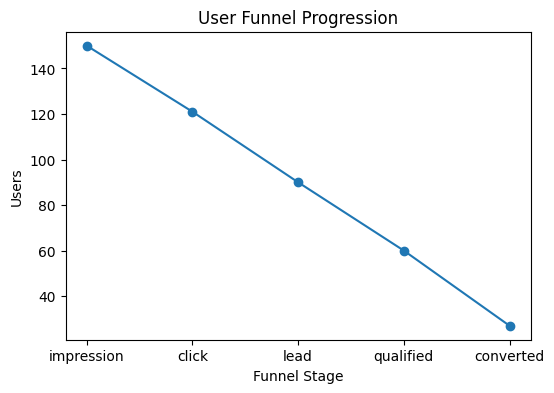

In [33]:
import matplotlib.pyplot as plt

stages = ["impression", "click", "lead", "qualified", "converted"]
counts = [funnel[stage].sum() for stage in stages]

plt.figure(figsize=(6,4))
plt.plot(stages, counts, marker="o")
plt.title("User Funnel Progression")
plt.xlabel("Funnel Stage")
plt.ylabel("Users")
plt.show()
